In [ ]:
import kagglehub
alexattia_the_simpsons_characters_dataset_path = kagglehub.dataset_download('alexattia/the-simpsons-characters-dataset')
print('Data source import complete.')

In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import shutil
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU доступен: {tf.config.list_physical_devices('GPU')}")

In [ ]:
df = pd.read_csv('/kaggle/input/the-simpsons-characters-dataset/annotation.txt', names=['filepath', 'x1', 'y1', 'x2', 'y2', 'character'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6752 entries, 0 to 6751
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   filepath   6752 non-null   object
 1   x1         6752 non-null   int64 
 2   y1         6752 non-null   int64 
 3   x2         6752 non-null   int64 
 4   y2         6752 non-null   int64 
 5   character  6752 non-null   object
dtypes: int64(4), object(2)
memory usage: 316.6+ KB


In [ ]:
uniq = df['character'].unique()
print(uniq)

['abraham_grampa_simpson' 'apu_nahasapeemapetilon' 'bart_simpson'
 'charles_montgomery_burns' 'chief_wiggum' 'comic_book_guy'
 'edna_krabappel' 'homer_simpson' 'kent_brockman' 'krusty_the_clown'
 'lisa_simpson' 'marge_simpson' 'milhouse_van_houten' 'moe_szyslak'
 'ned_flanders' 'nelson_muntz' 'principal_skinner' 'sideshow_bob']


Расхождение с реальным количеством персонажей (43)

In [ ]:
count  = df.groupby('character').size()
print(count)

character
abraham_grampa_simpson      595
apu_nahasapeemapetilon      206
bart_simpson                554
charles_montgomery_burns    650
chief_wiggum                209
comic_book_guy              208
edna_krabappel              212
homer_simpson               612
kent_brockman               213
krusty_the_clown            226
lisa_simpson                562
marge_simpson               557
milhouse_van_houten         210
moe_szyslak                 215
ned_flanders                595
nelson_muntz                219
principal_skinner           506
sideshow_bob                203
dtype: int64


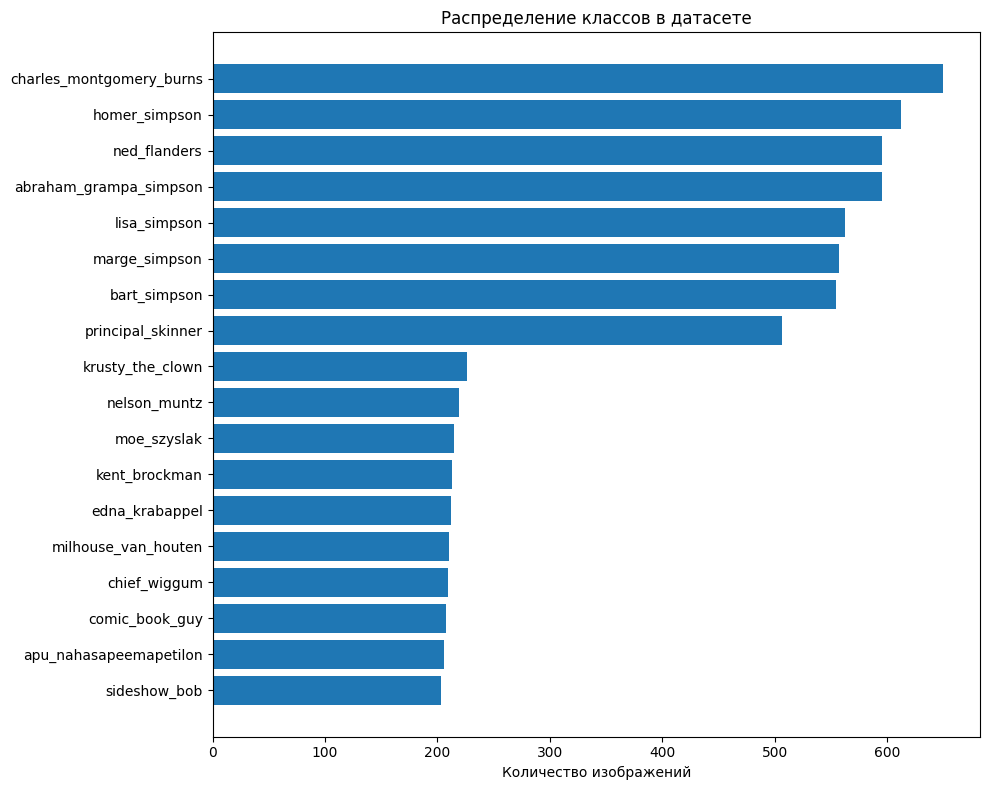

In [ ]:
count_sorted = count.sort_values()
plt.figure(figsize=(10, 8))
plt.barh(count_sorted.index, count_sorted.values)
plt.xlabel("Количество изображений")
plt.title("Распределение классов в датасете")
plt.tight_layout()
plt.show()

In [ ]:
df['filename'] = df['filepath'].apply(lambda x: os.path.basename(x))
df['class_name'] = df['character']
X = df[['filename', 'class_name']]
y = df['class_name']
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, stratify=y_test, random_state=42)
X_train, y_train = X_temp, y_temp

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 4726, Val: 1013, Test: 1013


In [ ]:
def copy_files(dataframe, split_name):
    print(f"Создание папок для {split_name}")

    for idx, row in dataframe.iterrows():
        char_folder = row['class_name']
        filename = row['filename']
        src_path = os.path.join('/kaggle/input/the-simpsons-characters-dataset/simpsons_dataset/', char_folder, filename)
        dst_dir = os.path.join('/working/clean_dataset/', split_name, char_folder)
        dst_path = os.path.join(dst_dir, filename)

        os.makedirs(dst_dir, exist_ok=True)

        if os.path.exists(src_path):
            shutil.copy(src_path, dst_path)
        else:
            print(f"Файл не найден: {src_path}")

copy_files(X_train, 'train')
copy_files(X_val, 'val')
copy_files(X_test, 'test')

print("Датасет создан")

Создание папок для train
Создание папок для val
Создание папок для test
Датасет создан


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 18

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/working/clean_dataset/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    '/working/clean_dataset/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    '/working/clean_dataset/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4725 images belonging to 18 classes.
Found 1013 images belonging to 18 classes.
Found 1013 images belonging to 18 classes.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5 to resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5


In [ ]:
base_model = ResNet50(
    weights='/content/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

In [ ]:
base_model.trainable = False

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Модель создана")

Модель создана


In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

checkpoint = keras.callbacks.ModelCheckpoint(
    '/content/best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

print("обучение верхних слоев")
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr, checkpoint]
)

print("\nдообучение с размороженной базой")
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr, checkpoint]
)

print("\nобучение завершено")

обучение верхних слоев
Epoch 1/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.0807 - loss: 3.0917

74/74 ━━━━━━━━━━━━━━━━━━━━ 762s 10s/step - accuracy: 0.0910 - loss: 2.8987 - val_accuracy: 0.1086 - val_loss: 2.7822 - learning_rate: 0.0010
Epoch 2/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.0965 - loss: 2.8070

74/74 ━━━━━━━━━━━━━━━━━━━━ 775s 10s/step - accuracy: 0.0938 - loss: 2.7972 - val_accuracy: 0.1145 - val_loss: 2.7558 - learning_rate: 0.0010
Epoch 3/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.0913 - loss: 2.8009

74/74 ━━━━━━━━━━━━━━━━━━━━ 759s 10s/step - accuracy: 0.1001 - loss: 2.7898 - val_accuracy: 0.1175 - val_loss: 2.7742 - learning_rate: 0.0010
Epoch 4/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 681s 9s/step - accuracy: 0.1039 - loss: 2.7866 - val_accuracy: 0.1106 - val_loss: 2.7456 - learning_rate: 0.0010
Epoch 5/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.1043 - loss: 2.7698

74/74 ━━━━━━━━━━━━━━━━━━━━ 732s 10s/step - accuracy: 0.1035 - loss: 2.7760 - val_accuracy: 0.1343 - val_loss: 2.7541 - learning_rate: 0.0010

дообучение с размороженной базой
Epoch 1/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 1458s 19s/step - accuracy: 0.1067 - loss: 2.8052 - val_accuracy: 0.0859 - val_loss: 2.7850 - learning_rate: 1.0000e-04
Epoch 2/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.1241 - loss: 2.7585 

74/74 ━━━━━━━━━━━━━━━━━━━━ 1362s 18s/step - accuracy: 0.1221 - loss: 2.7730 - val_accuracy: 0.1352 - val_loss: 2.7361 - learning_rate: 1.0000e-04
Epoch 3/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.1300 - loss: 2.7606 

74/74 ━━━━━━━━━━━━━━━━━━━━ 1354s 18s/step - accuracy: 0.1329 - loss: 2.7492 - val_accuracy: 0.1649 - val_loss: 2.6735 - learning_rate: 1.0000e-04
Epoch 4/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.1522 - loss: 2.7216 

74/74 ━━━━━━━━━━━━━━━━━━━━ 1251s 17s/step - accuracy: 0.1465 - loss: 2.7264 - val_accuracy: 0.1787 - val_loss: 2.6300 - learning_rate: 1.0000e-04
Epoch 5/5
74/74 ━━━━━━━━━━━━━━━━━━━━ 1176s 16s/step - accuracy: 0.1386 - loss: 2.7344 - val_accuracy: 0.1293 - val_loss: 2.7313 - learning_rate: 1.0000e-04

✅ Обучение завершено!


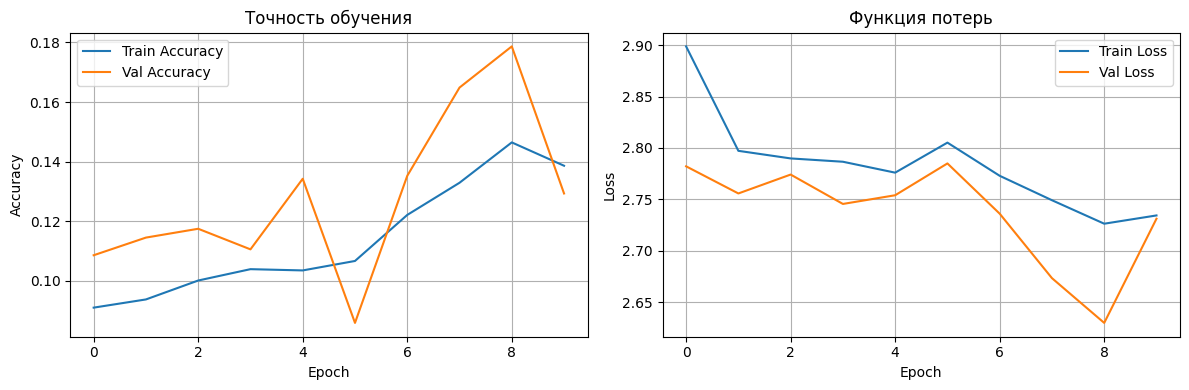

Тестирование на test выборке...
16/16 ━━━━━━━━━━━━━━━━━━━━ 126s 8s/step - accuracy: 0.1698 - loss: 2.6417

Test Accuracy: 0.1698
Test Loss: 2.6417


In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Точность обучения')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'] + history_fine.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'] + history_fine.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Функция потерь')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("Тестирование на test выборке...")
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 118s 7s/step


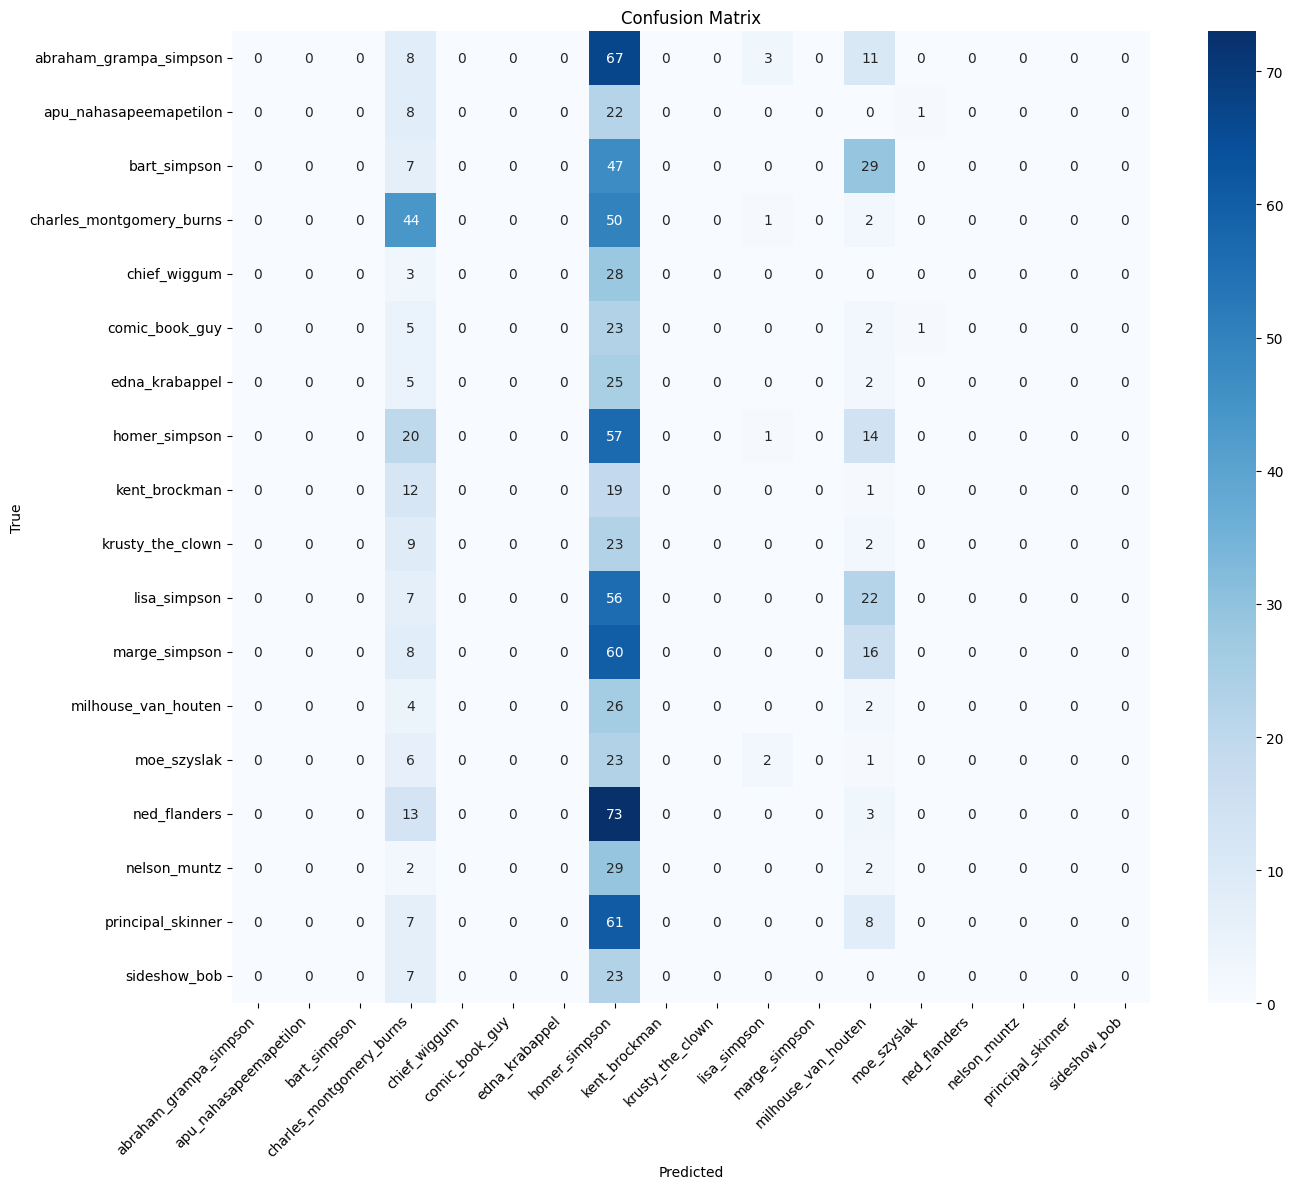


Classification Report:
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.00      0.00      0.00        89
  apu_nahasapeemapetilon       0.00      0.00      0.00        31
            bart_simpson       0.00      0.00      0.00        83
charles_montgomery_burns       0.25      0.45      0.32        97
            chief_wiggum       0.00      0.00      0.00        31
          comic_book_guy       0.00      0.00      0.00        31
          edna_krabappel       0.00      0.00      0.00        32
           homer_simpson       0.08      0.62      0.14        92
           kent_brockman       0.00      0.00      0.00        32
        krusty_the_clown       0.00      0.00      0.00        34
            lisa_simpson       0.00      0.00      0.00        85
           marge_simpson       0.00      0.00      0.00        84
     milhouse_van_houten       0.02      0.06      0.03        32
             moe_szyslak       0.00      0.00      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys()))